# Pathology Prediction — Enlarged Cardiomediastinum

**Reference:** Soenksen, L.R., Ma, Y., Zeng, C. et al. Integrated multimodal artificial intelligence framework for healthcare applications. *npj Digit. Med.* 5, 149 (2022). https://doi.org/10.1038/s41746-022-00689-4

This notebook replicates the HAIM experiment for the **Enlarged Cardiomediastinum** prediction task using a subset of multimodal sources (`de`, `vp`, `vmp`, `ts_ce`, `ts_pe`). It also validates that compressing the dataset from `float64` to `float32` does not degrade model performance — a necessary step for integration into MEDomics.

## 1. Setup

Import dependencies and load the HAIM dataset.
> **Note:** Update `constants.FILE_DF` to point to your local copy of the HAIM-MIMIC-MM CSV file. Access requires a PhysioNet credentialed account.

In [ ]:
import os
os.chdir('../')

from xgboost import XGBClassifier
from pandas import read_csv

from src.data import constants
from src.data.sampling import Sampler
from src.evaluation.evaluating import Evaluator
from src.evaluation.tuning import SklearnTuner
from src.evaluation.metrics import (
    BinaryAccuracy, BinaryBalancedAccuracy, Sensitivity,
    Specificity, AUC, BrierScore, BinaryCrossEntropy, Reduction
)
from src.data.dataset_adapted_poc import HAIMDataset, ENLARGED_CARDIOMEDIASTINUM

In [ ]:
df = read_csv(constants.FILE_DF, nrows=constants.N_DATA)

## 2. Dataset Construction

Build the task-specific dataset using the adapted `HAIMDataset` class.
Sources selected: demographics (`de`), visual probabilities (`vp`, `vmp`), and time-series chart/procedure events (`ts_ce`, `ts_pe`).

> Radiology notes are excluded to match the configuration used in the HAIM supplementary material (combination 3 and 4).

In [ ]:
sources = ['de', 'vp', 'vmp', 'ts_ce', 'ts_pe']

dataset = HAIMDataset(
    original_dataset=df,
    task=ENLARGED_CARDIOMEDIASTINUM,
    ids='img_id',
    global_ids='haim_id',
    source_names=sources
)

print("Features:", dataset.n_features)
print("Samples:", len(dataset))


 HAIMDataset  |  Tâche : Enlarged Cardiomediastinum
  [tabular     ] de       :     6 features  (Demographics)
  [images      ] vp       :    18 features  (Visual probabilities)
  [images      ] vmp      :    18 features  (Aggregated visual probabilities)
  [time_series ] ts_ce    :    99 features  (Chart events)
  [time_series ] ts_pe    :   110 features  (Procedure events)
               TOTAL    :   251 features

 Observations : 3206 | Positifs : 2388 (74.5%) | Features : 251

Features: 251
Samples: 3206


## 3. Experimental Protocol (Original HAIM)

Replicate the HAIM cross-validation protocol:
- 5-fold CV stratified on unique `haim_id`
- XGBoost classifier with GridSearchCV hyperparameter tuning
- Metrics: AUC, Accuracy, Balanced Accuracy, Sensitivity, Specificity

In [ ]:
sampler = Sampler(dataset, constants.GLOBAL_ID, 5)
_, masks = sampler()

In [ ]:
evaluation_metrics = [
    BinaryAccuracy(),
    BinaryBalancedAccuracy(),
    BinaryBalancedAccuracy(Reduction.GEO_MEAN),
    Sensitivity(),
    Specificity(),
    AUC(),
    BrierScore(),
    BinaryCrossEntropy()
]

In [ ]:
# Hyperparameter grid (matches HAIM paper configuration)
grid_hps = {
    'max_depth': [5, 6, 7, 8],
    'n_estimators': [200, 300],
    'learning_rate': [0.3, 0.1, 0.05],
}

fixed_params = {
    'seed': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False
}

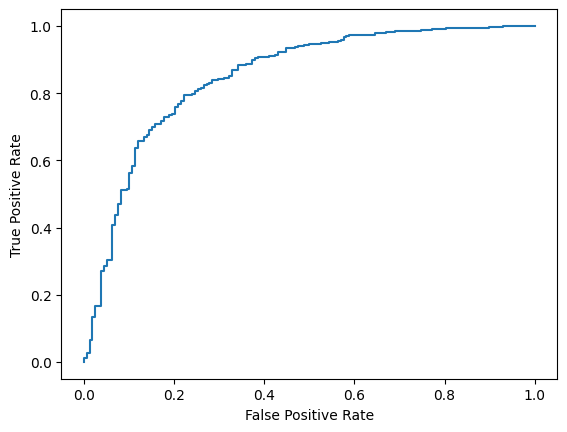

In [ ]:
evaluation_ecm = Evaluator(
    dataset=dataset,
    masks=masks,
    metrics=evaluation_metrics,
    model=XGBClassifier,
    tuner=SklearnTuner,
    tuning_metric=AUC(),
    hps=grid_hps,
    n_tuning_splits=5,
    fixed_params=fixed_params,
    filepath=constants.EXPERIMENT_PATH + 'CP_Enlarged Cardiomediastinum-poc0'
)

### Comparison with HAIM paper results

Visualize results against the values reported in the HAIM supplementary material.

In [ ]:
Evaluator.visualize_results(
    'experiments/CP_Enlarged Cardiomediastinum-poc0',
    constants.ENLARGED_CARDIOMEDIASTINUM
)

,Accuracy,BalancedAcc,GeoBalancedAcc,Sensitivity,Specificity,AUC,BrierScore,BCE
train_metrics,0.9998 +- 0.0003,0.9999 +- 0.0002,0.9999 +- 0.0002,0.9998 +- 0.0004,1.0 +- 0.0,1.0 +- 0.0,0.0051 +- 0.0044,0.0471 +- 0.0278
test_metrics,0.806 +- 0.0247,0.7092 +- 0.0248,0.6797 +- 0.0368,0.9041 +- 0.0349,0.5144 +- 0.0684,0.8143 +- 0.0265,0.1457 +- 0.0178,0.4925 +- 0.0771
HAIM,--,--,--,--,--,0.876,--,--
NON_HAIM,--,--,--,--,--,0.868,--,--


## 4. Compression Validation

Validate that compressing features from `float64` to `float32` (scaled by a factor of 100,000) does not degrade model performance. This compression is required to reduce memory footprint for MEDomics integration.

> `float32` is used instead of `float16` to preserve NaN values, which are not supported by `float16` in pandas.

In [ ]:
compressed_df = dataset.save_to_csv(
    "compressed_dataset_enlarged_cm.csv",
    drop_ids=False,
    compress=True,
    return_df=True
)


Dataset sauvegardé : compressed_dataset1.csv
Shape : (3206, 257)
Features sélectionnées : 251
Taille mémoire estimée : 3.77 MB



In [ ]:
# Rebuild dataset from compressed data
dataset_compressed = HAIMDataset(
    original_dataset=compressed_df,
    task=ENLARGED_CARDIOMEDIASTINUM,
    ids='img_id',
    global_ids='haim_id',
    source_names=sources
)


 HAIMDataset  |  Tâche : Enlarged Cardiomediastinum
  [tabular     ] de       :     6 features  (Demographics)
  [images      ] vp       :    18 features  (Visual probabilities)
  [images      ] vmp      :    18 features  (Aggregated visual probabilities)
  [time_series ] ts_ce    :    99 features  (Chart events)
  [time_series ] ts_pe    :   110 features  (Procedure events)
               TOTAL    :   251 features

 Observations : 3206 | Positifs : 2388 (74.5%) | Features : 251



In [ ]:
print("Shape:", compressed_df.shape)
print("Columns sample:", compressed_df.columns.tolist()[:10])

(3206, 257)
['de_0', 'de_1', 'de_2', 'de_3', 'de_4', 'de_5', 'vp_0', 'vp_1', 'vp_2', 'vp_3', 'vp_4', 'vp_5', 'vp_6', 'vp_7', 'vp_8', 'vp_9', 'vp_10', 'vp_11', 'vp_12', 'vp_13', 'vp_14', 'vp_15', 'vp_16', 'vp_17', 'vmp_0', 'vmp_1', 'vmp_2', 'vmp_3', 'vmp_4', 'vmp_5', 'vmp_6', 'vmp_7', 'vmp_8', 'vmp_9', 'vmp_10', 'vmp_11', 'vmp_12', 'vmp_13', 'vmp_14', 'vmp_15', 'vmp_16', 'vmp_17', 'ts_ce_0', 'ts_ce_1', 'ts_ce_2', 'ts_ce_3', 'ts_ce_4', 'ts_ce_5', 'ts_ce_6', 'ts_ce_7', 'ts_ce_8', 'ts_ce_9', 'ts_ce_10', 'ts_ce_11', 'ts_ce_12', 'ts_ce_13', 'ts_ce_14', 'ts_ce_15', 'ts_ce_16', 'ts_ce_17', 'ts_ce_18', 'ts_ce_19', 'ts_ce_20', 'ts_ce_21', 'ts_ce_22', 'ts_ce_23', 'ts_ce_24', 'ts_ce_25', 'ts_ce_26', 'ts_ce_27', 'ts_ce_28', 'ts_ce_29', 'ts_ce_30', 'ts_ce_31', 'ts_ce_32', 'ts_ce_33', 'ts_ce_34', 'ts_ce_35', 'ts_ce_36', 'ts_ce_37', 'ts_ce_38', 'ts_ce_39', 'ts_ce_40', 'ts_ce_41', 'ts_ce_42', 'ts_ce_43', 'ts_ce_44', 'ts_ce_45', 'ts_ce_46', 'ts_ce_47', 'ts_ce_48', 'ts_ce_49', 'ts_ce_50', 'ts_ce_51', 'ts

In [ ]:
# Re-create sampler on compressed dataset
sampler = Sampler(dataset_compressed, constants.GLOBAL_ID, 5)
_, masks = sampler()

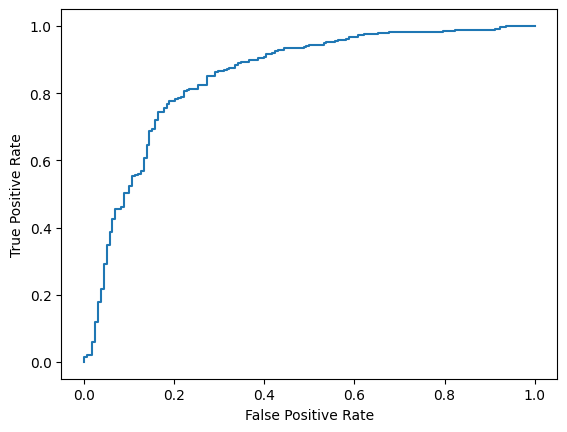

In [ ]:
evaluation_ecm_compressed = Evaluator(
    dataset=dataset_compressed,
    masks=masks,
    metrics=evaluation_metrics,
    model=XGBClassifier,
    tuner=SklearnTuner,
    tuning_metric=AUC(),
    hps=grid_hps,
    n_tuning_splits=5,
    fixed_params=fixed_params,
    filepath=constants.EXPERIMENT_PATH + 'CP_Enlarged Cardiomediastinum-compressed'
)

### Results comparison: original vs compressed

In [ ]:
Evaluator.visualize_results(
    'experiments/CP_Enlarged Cardiomediastinum-compressed',
    constants.ENLARGED_CARDIOMEDIASTINUM
)

,Accuracy,BalancedAcc,GeoBalancedAcc,Sensitivity,Specificity,AUC,BrierScore,BCE
train_metrics,0.9995 +- 0.0009,0.9997 +- 0.0006,0.9997 +- 0.0006,0.9994 +- 0.0012,1.0 +- 0.0,1.0 +- 0.0,0.005 +- 0.0051,0.0452 +- 0.0267
test_metrics,0.8047 +- 0.0265,0.715 +- 0.0218,0.6873 +- 0.0318,0.902 +- 0.0475,0.528 +- 0.0736,0.8183 +- 0.0223,0.1426 +- 0.0163,0.4728 +- 0.0538
HAIM,--,--,--,--,--,0.876,--,--
NON_HAIM,--,--,--,--,--,0.868,--,--
